In [11]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from src.data_prep import load_and_prepare
from src.t_learner import run_two_model
from src.uplift_trees import train_uplift_rf
from src.meta_learners import run_x_learner
from src.evaluation import sample_qini_curves, plot_qini_distribution
from src.stability import run_stability_check

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def make_run_lookup(arm, outcome):

    def run_lookup(split_seed, model_seed, model_type):
        X_train, X_test, y_train, y_test, treatment_train, treatment_test = \
            load_and_prepare(treatment_arm=arm, random_state=split_seed)

        if model_type == "T-Learner":
            uplift_scores = run_two_model(
                X_train, treatment_train, y_train[outcome], X_test,
                random_state=model_seed, n_jobs=-1
            )
        elif model_type == "Uplift Trees":
            uplift_scores = train_uplift_rf(
                X_train, treatment_train, y_train[outcome], X_test,
                random_state=model_seed, max_depth=8, n_estimators=300,
                evaluationFunction="KL", n_jobs=-1
            )
        elif model_type == "X-Learner":
            uplift_scores = run_x_learner(
                X_train, treatment_train, y_train[outcome], X_test,
                random_state=model_seed, n_jobs=-1
            )

        return uplift_scores, treatment_test, y_test[outcome]

    return run_lookup

In [3]:
df_visit = run_stability_check(
    n_splits=30,
    n_model_seeds=2,
    models=("T-Learner", "Uplift Trees", "X-Learner"),
    arm="Womens E-Mail",
    outcome="visit",
    max_workers=12
)

print(df_visit.groupby("model")["qini_coefficient"].agg(["mean", "std", "count"]))

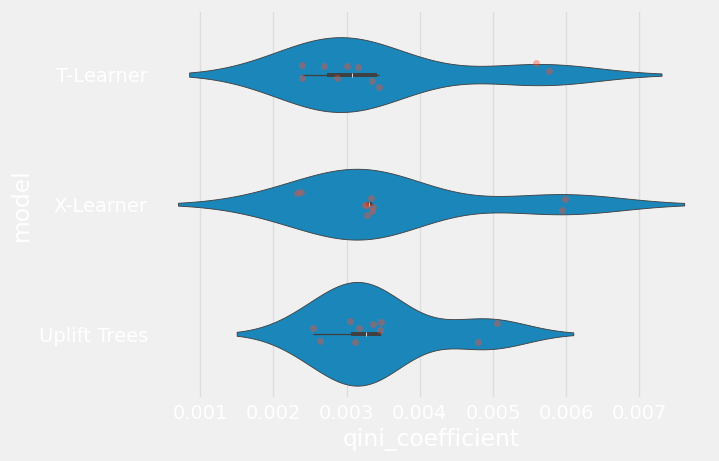

In [4]:
ax = plot_qini_distribution(df_visit, metric="qini_coefficient")
ax.set_facecolor("black")
plt.show()

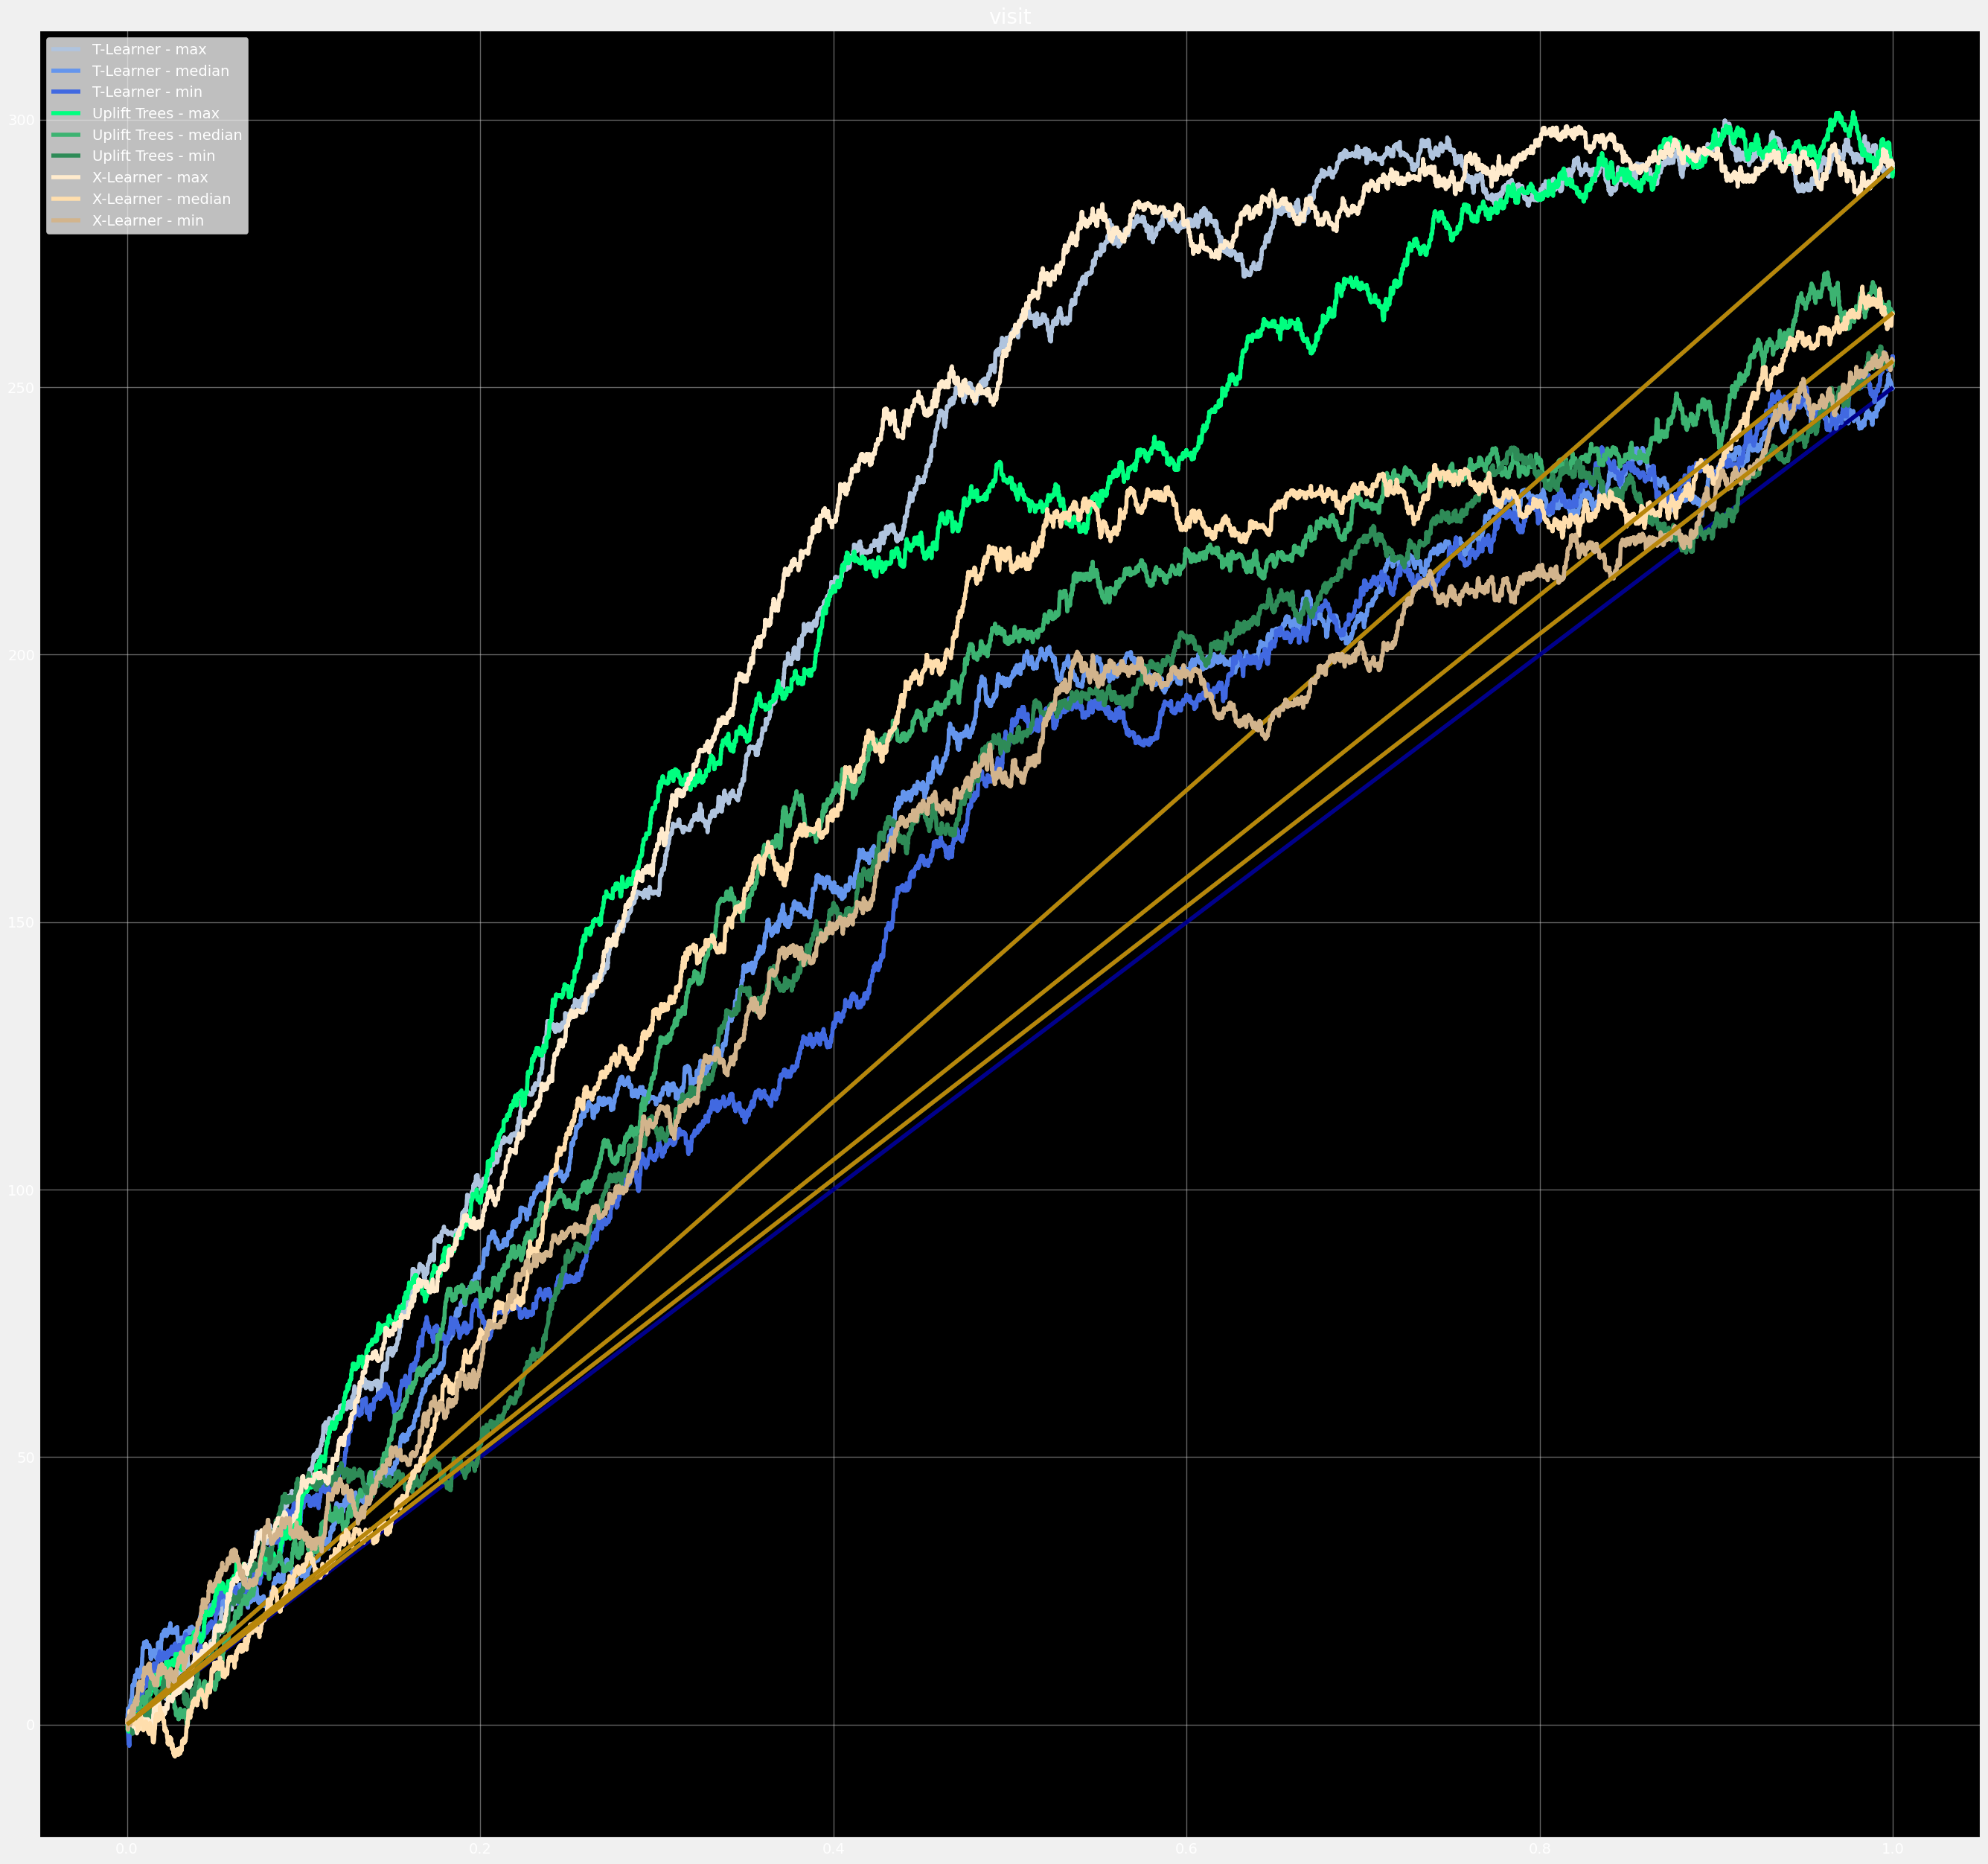

In [12]:
run_lookup = make_run_lookup(arm="Womens E-Mail", outcome="visit")

fig, ax = plt.subplots(figsize=(30, 30))

for model, colors in {
                      "T-Learner": [["lightsteelblue", "cornflowerblue", "royalblue"], "darkblue"],
                      "Uplift Trees": [["springgreen", "mediumseagreen", "seagreen"], "darkgreen"],
                      "X-Learner": [["blanchedalmond", "navajowhite", "tan"], "darkgoldenrod"]
}.items():
    sample_qini_curves(df_visit, run_lookup, model, curve_colors=colors[0], diagonal_color=colors[1], ax=ax)

ax.set_facecolor("black")
plt.show()

In [7]:
df_conversion = run_stability_check(
    n_splits=30,
    n_model_seeds=2,
    models=("T-Learner", "Uplift Trees", "X-Learner"),
    arm="Womens E-Mail",
    outcome="conversion",
    max_workers=12
)

print(df_conversion.groupby("model")["qini_coefficient"].agg(["mean", "std", "count"]))

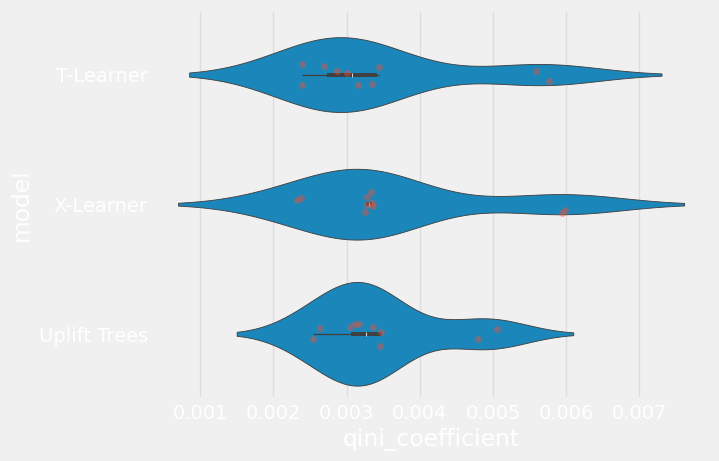

In [8]:
ax = plot_qini_distribution(df_visit, metric="qini_coefficient")
ax.set_facecolor("black")
plt.show()

In [ ]:
run_lookup = make_run_lookup(arm="Womens E-Mail", outcome="conversion")

fig, ax = plt.subplots(figsize=(30, 30))

for model, colors in {
                      "T-Learner": [["lightsteelblue", "cornflowerblue", "royalblue"], "darkblue"],
                      "Uplift Trees": [["springgreen", "mediumseagreen", "seagreen"], "darkgreen"],
                      "X-Learner": [["blanchedalmond", "navajowhite", "tan"], "darkgoldenrod"]
}.items():
    sample_qini_curves(df_visit, run_lookup, model, curve_colors=colors[0], diagonal_color=colors[1], ax=ax)

ax.set_facecolor("black")
plt.show()